In [26]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

In [266]:
tickers = [
    "NIFTYBEES.NS",
    "JUNIORBEES.NS",
    "GOLDBEES.NS",
    "LIQUIDCASE.NS"
]

In [296]:
end_date = datetime.today()
start_date = end_date - timedelta(days=2 * 365)

In [297]:
adj_close_df = pd.DataFrame()

In [298]:
for ticker in tickers:
    data = yf.download(
        ticker,
        start=start_date,
        end=end_date,
    )

    adj_close_df[ticker] = data["Close"]

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [299]:
print(adj_close_df.head())

            NIFTYBEES.NS  JUNIORBEES.NS  GOLDBEES.NS  LIQUIDCASE.NS
Date                                                               
2024-10-03    282.690002     807.630005    63.689999     104.629997
2024-10-04    280.149994     803.200012    63.990002     104.690002
2024-10-07    278.010010     784.969971    63.810001     104.690002
2024-10-08    279.399994     796.030029    63.450001     104.720001
2024-10-09    278.720001     804.700012    63.020000     104.730003


In [300]:
log_returns = np.log(adj_close_df / adj_close_df.shift(1))
log_returns = log_returns.dropna()

In [301]:
print(log_returns.head())

            NIFTYBEES.NS  JUNIORBEES.NS  GOLDBEES.NS  LIQUIDCASE.NS
Date                                                               
2024-10-04     -0.009026      -0.005500     0.004699       0.000573
2024-10-07     -0.007668      -0.022958    -0.002817       0.000000
2024-10-08      0.004987       0.013991    -0.005658       0.000287
2024-10-09     -0.002437       0.010833    -0.006800       0.000096
2024-10-10      0.002079      -0.001741    -0.000159       0.000191


In [303]:
cov_matrix = log_returns.cov() * 256

In [304]:
cov_matrix

,NIFTYBEES.NS,JUNIORBEES.NS,GOLDBEES.NS,LIQUIDCASE.NS
NIFTYBEES.NS,0.015161,0.017879,0.005881,-0.000007
JUNIORBEES.NS,0.017879,0.030272,0.008616,-0.000034
GOLDBEES.NS,0.005881,0.008616,0.066766,-0.000005
LIQUIDCASE.NS,-0.000007,-0.000034,-0.000005,0.000007


In [305]:
def standard_deviation(weights, cov_matrix):
    variance = weights.T @ cov_matrix @ weights
    
    return np.sqrt(variance)

In [306]:
def expected_returns(weights, log_returns):
    return np.sum(log_returns.mean() * weights) * 256

In [307]:
def sharp_ratio(weights, log_returns, cov_matrix, risk_free_rate):
    return (expected_returns(weights, log_returns) - risk_free_rate) / standard_deviation(weights, cov_matrix)

In [308]:
risk_free_rate = 0

In [309]:
def neg_sharp_ratio(weights, log_returns, cov_matrix, risk_free_rate):
    return -1 * sharp_ratio(weights, log_returns, cov_matrix, risk_free_rate)

In [310]:
constraints = { "type": "eq", "fun": lambda weights: np.sum(weights) - 1 }
bounds = [(0.1, 0.5) for _ in range(len(tickers))]

In [311]:
initial_weights = np.array([1 / len(tickers)] * len(tickers))
print(initial_weights)

[0.25 0.25 0.25 0.25]


In [312]:
optimized_results = minimize(
    neg_sharp_ratio,
    initial_weights,
    args=(log_returns, cov_matrix, risk_free_rate),
    method="SLSQP",
    constraints=constraints,
    bounds=bounds
)

In [313]:
optimal_weights = optimized_results.x

print("Optimal Weights:")
for ticker, weight in zip(tickers, optimal_weights):
    print(f"{ticker}: {weight:.4f}")

optimal_portfolio_return = expected_returns(optimal_weights, log_returns)
optimal_portfolio_volatility = standard_deviation(optimal_weights, cov_matrix)
optimal_sharpe_ratio = sharp_ratio(optimal_weights, log_returns, cov_matrix, risk_free_rate)

print(f"Expected Annual Return: {optimal_portfolio_return:.4f}")
print(f"Expected Volatility: {optimal_portfolio_volatility:.4f}")
print(f"Sharpe Ratio: {optimal_sharpe_ratio:.4f}")

Optimal Weights:
NIFTYBEES.NS: 0.1000
JUNIORBEES.NS: 0.1000
GOLDBEES.NS: 0.3000
LIQUIDCASE.NS: 0.5000
Expected Annual Return: 0.1173
Expected Volatility: 0.0877
Sharpe Ratio: 1.3375


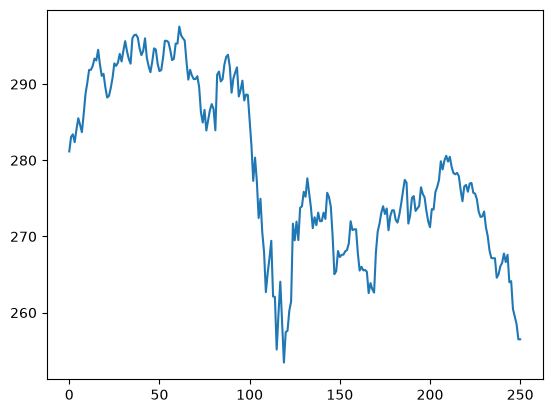

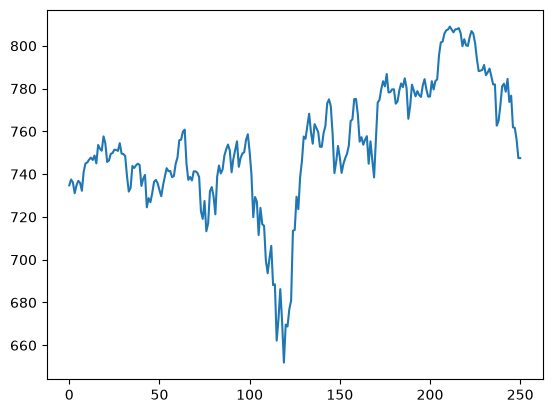

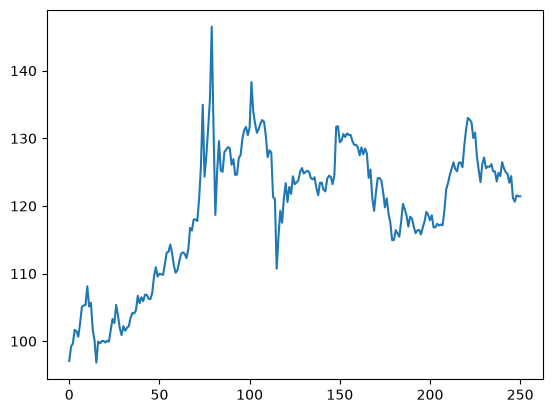

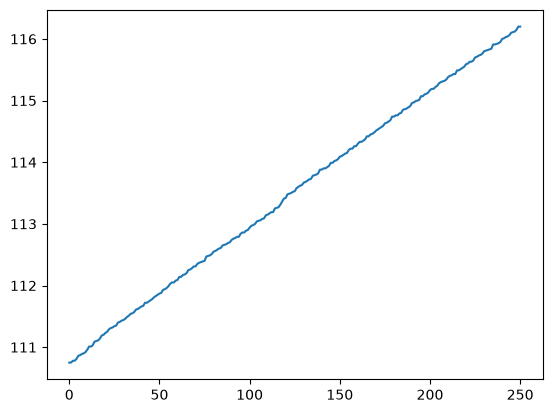

In [284]:
for ticker in tickers:
    plt.plot(adj_close_df[ticker].values)
    plt.show()